In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.offsetbox import AnchoredText
from tqdm import tqdm

from ncs.compressed_sensing_module import measure_and_reconstruct
from ncs.sparse_signal_generator import generate_tree_sparse_coeffs, add_noise_to_coeffs
from ncs.wavelet_module import inverse_transform

In [3]:
def generate_noisy_signal_reconstruction_data(
        n_power,
        tree_sparsity,
        noise_epsilon,
        noise_mode,
        wavelet,
        measurement_mode,
        reconstruction_mode,
        signal_count,
        reconstruction_attempts,
        m_values,
) -> pd.DataFrame:
    sparse_coeffs = generate_tree_sparse_coeffs(
        power=n_power,
        count=signal_count,
        tree_sparsity=tree_sparsity,
        wavelet=wavelet,
    )
    noisy_coeffs = add_noise_to_coeffs(sparse_coeffs, noise_epsilon, noise_mode)

    results = []
    for m in tqdm(m_values, desc="Measuring and reconstructing"):
        for sparse_coeff, noisy_coeff in zip(sparse_coeffs, noisy_coeffs):
            for _ in range(reconstruction_attempts):
                x_hat = measure_and_reconstruct(
                    measurement_mode=measurement_mode,
                    m=int(m),
                    reconstruction_mode=reconstruction_mode,
                    coeffs_x=noisy_coeff,
                    target_tree_sparsity=tree_sparsity,
                )

                sparse_z = inverse_transform(sparse_coeff)
                reconstructed_z = inverse_transform(x_hat)

                missed_support_len = len(sparse_coeff.support - x_hat.support)
                mse = np.mean((sparse_z - reconstructed_z) ** 2)

                results.append({
                    'm': m,
                    'mse': mse,
                    'missed_support': missed_support_len
                })
    return pd.DataFrame(results)


In [4]:
def plot_reconstruction_results(
        df,
        n,
        tree_sparsity,
        noise_epsilon,
        noise_mode,
        wavelet,
        measurement_mode,
        reconstruction_mode,
        signal_count,
        reconstruction_attempts,
        m_values,
):
    params = {
        "N": n,
        "Tree-sparsity": tree_sparsity,
        "Noise-Epsilon": noise_epsilon,
        "Noise-Mode": noise_mode,
        "Wavelet": wavelet,
        "Measurement": measurement_mode,
        "Reconstruction": reconstruction_mode,
        "Signals": signal_count,
        "Reconstructions per signal": reconstruction_attempts,
    }
    param_str = "\n".join([f"{k}: {v}" for k, v in params.items()])

    fig, ax = plt.subplots(figsize=(12, 8))

    sns.stripplot(
        data=df,
        x='m',
        y='mse',
        hue='missed_support',
        jitter=0.2,
        alpha=0.7,
        palette='RdYlGn_r',
        native_scale=True,
        ax=ax
    )

    sns.lineplot(
        data=df,
        x='m',
        y='mse',
        estimator='mean',
        color='blue',
        linewidth=2,
        errorbar=None,
        ax=ax,
        label='Mean MSE'
    )

    ax.set_xlabel(f'Number of Measurements (m {m_values.min()} - {m_values.max()})', fontsize=12)
    ax.set_ylabel('Signal domain MSE', fontsize=12)
    ax.set_title(f'Noisy tree-sparse signal reconstruction: MSE vs Number of Measurements', fontsize=14)
    ax.grid(True, alpha=0.3)

    ax.legend(title='Missed Support', fontsize=10, loc='upper right')

    at = AnchoredText(
        s=param_str,
        loc='upper right',
        bbox_to_anchor=(1, 0.73),  # adjusted manually
        bbox_transform=ax.transAxes,
        frameon=True
    )
    ax.add_artist(at)

    plt.tight_layout()
    plt.show()

In [5]:
m_values = np.linspace(15, 200, 20, dtype=int)

Measuring and reconstructing: 100%|██████████| 20/20 [01:13<00:00,  3.65s/it]


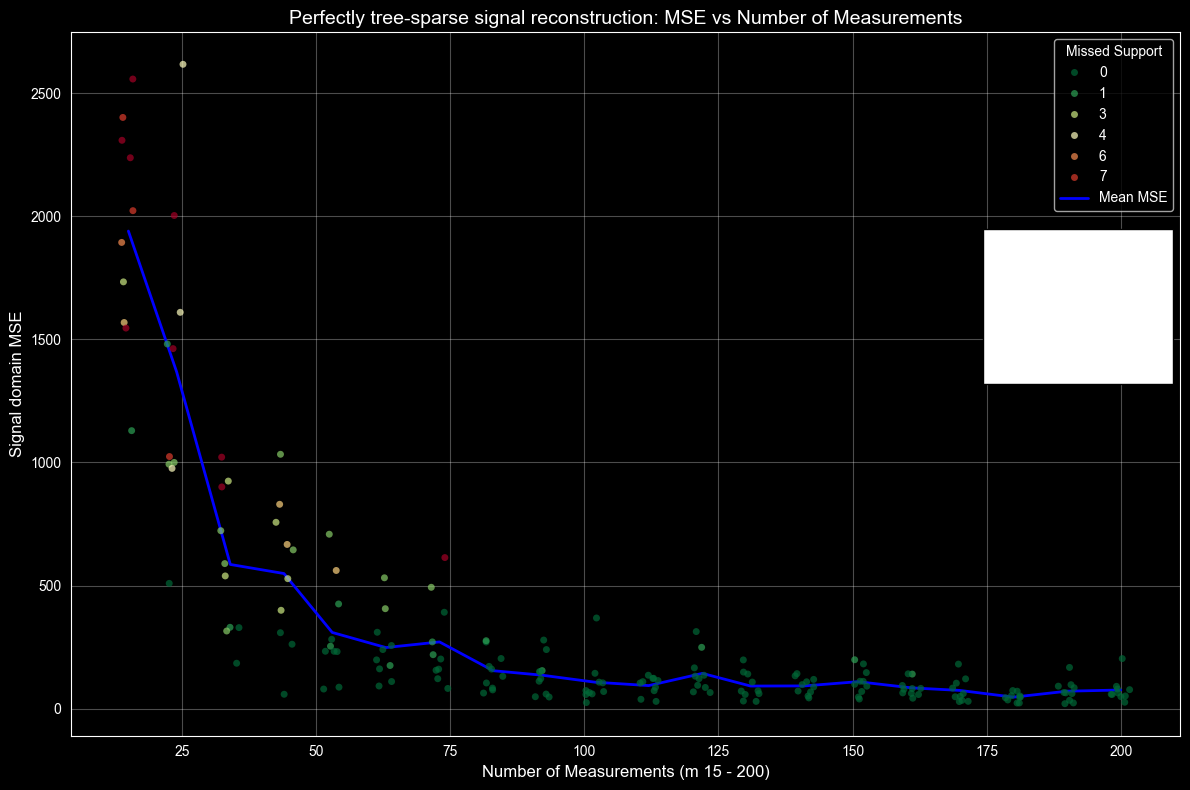

In [6]:
df = generate_noisy_signal_reconstruction_data(
    n_power=10,
    tree_sparsity=10,
    noise_epsilon=1e-1,
    noise_mode="gaussian",
    wavelet='haar',
    measurement_mode="gaussian",
    reconstruction_mode="CoSaMP",
    signal_count=5,
    reconstruction_attempts=2,
    m_values=m_values,
)
plot_reconstruction_results(
    df=df,
    n=2 ** 10,
    tree_sparsity=10,
    noise_epsilon=1e-1,
    noise_mode="gaussian",
    wavelet='haar',
    measurement_mode="gaussian",
    reconstruction_mode="CoSaMP",
    signal_count=5,
    reconstruction_attempts=2,
    m_values=m_values,
)

Measuring and reconstructing: 100%|██████████| 20/20 [01:13<00:00,  3.69s/it]


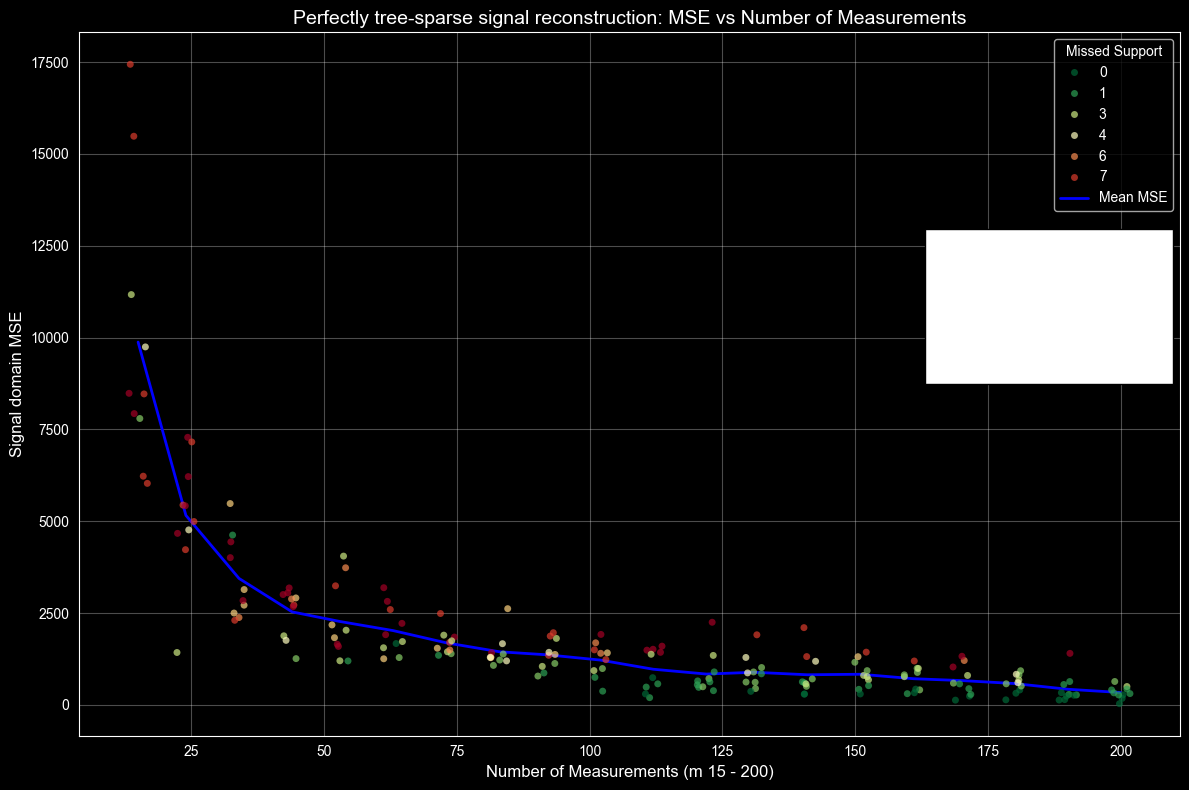

In [7]:
df = generate_noisy_signal_reconstruction_data(
    n_power=10,
    tree_sparsity=10,
    noise_epsilon=3*1e-1,
    noise_mode="gaussian",
    wavelet='haar',
    measurement_mode="gaussian",
    reconstruction_mode="CoSaMP",
    signal_count=5,
    reconstruction_attempts=2,
    m_values=m_values,
)
plot_reconstruction_results(
    df=df,
    n=2 ** 10,
    tree_sparsity=10,
    noise_epsilon=3*1e-1,
    noise_mode="gaussian",
    wavelet='haar',
    measurement_mode="gaussian",
    reconstruction_mode="CoSaMP",
    signal_count=5,
    reconstruction_attempts=2,
    m_values=m_values,
)

Measuring and reconstructing: 100%|██████████| 20/20 [03:59<00:00, 11.95s/it]


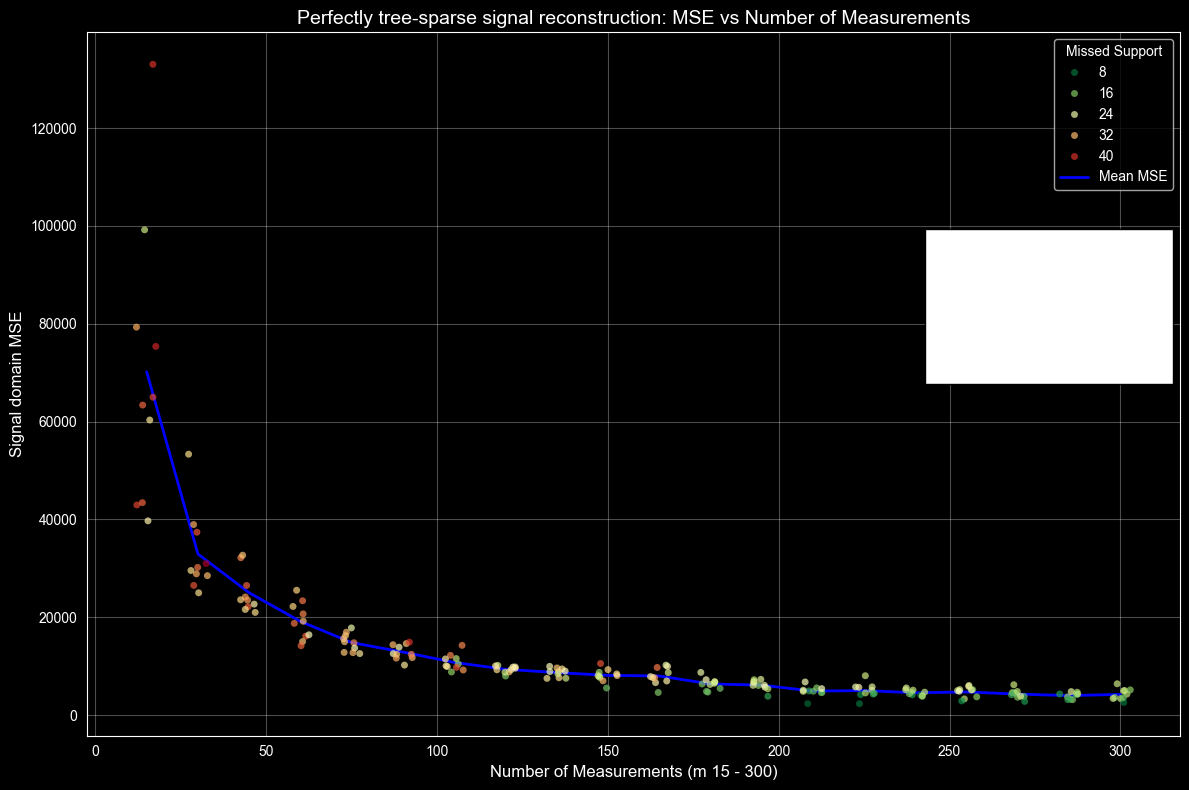

In [8]:
m_values = np.linspace(15, 300, 20, dtype=int)
df = generate_noisy_signal_reconstruction_data(
    n_power=10,
    tree_sparsity=50,
    noise_epsilon=3*1e-1,
    noise_mode="gaussian",
    wavelet='haar',
    measurement_mode="gaussian",
    reconstruction_mode="CoSaMP",
    signal_count=5,
    reconstruction_attempts=2,
    m_values=m_values,
)
plot_reconstruction_results(
    df=df,
    n=2 ** 10,
    tree_sparsity=50,
    noise_epsilon=3*1e-1,
    noise_mode="gaussian",
    wavelet='haar',
    measurement_mode="gaussian",
    reconstruction_mode="CoSaMP",
    signal_count=5,
    reconstruction_attempts=2,
    m_values=m_values,
)